In [1]:
import h5py

In [2]:
# modisco_counts = h5py.File("/oak/stanford/groups/akundaje/projects/chromatin-atlas-2022/chrombpnet/folds/ATAC/GM12878/merge_folds_new_may_05_24/counts/modisco_counts.h5", 'r'
#          )

In [3]:
# num=0
# for key in modisco_counts['pos_patterns'].keys():
#     num+=modisco_counts['pos_patterns'][key]['seqlets']['n_seqlets'].value
# for key in modisco_counts['neg_patterns'].keys():
#     num+=modisco_counts['neg_patterns'][key]['seqlets']['n_seqlets'].value

In [4]:
# num

In [5]:
# 193107*100/1000000

In [6]:
import pandas as pd

In [7]:
df = pd.read_csv("/mnt/lab_data2/anusri/finemo_gpu/output/572M/motif_report.tsv", sep='\t')

In [8]:
df['num_seqlets'].sum()

191202

In [9]:
#df

In [10]:
idir="/mnt/lab_data2/anusri/chrombpnet/src/evaluation/figure_notebooks/reviews/finemo/"
hits_inpeaks = pd.read_csv(idir+"hits_inpeaks.bed", sep="\t", header=None)
outside_hits = pd.read_csv(idir+"outside_hits.bed", sep="\t", header=None)


In [11]:
hits_inpeaks.shape

(614489, 3)

In [13]:
outside_hits.shape

(259991, 3)

In [14]:
import pyBigWig as pw
bigwigs="/mnt/lab_data2/anusri/chrombpnet/results/chrombpnet/ATAC_PE/GM12878/nautilus_runs/GM12878_03.01.2022_bias_128_4_1234_0.4_fold_0/interpret/merged.GM12878.counts.bw"
bw = pw.open(bigwigs)

In [15]:
import numpy as np
def running_average_non_overlapping(arr, window_width=3):
    # Ensure the length of the array is divisible by the window width
    arr_length = len(arr)
    if arr_length % window_width != 0:
        num_windows = arr_length // window_width
        
        # Truncate the array to make its length divisible by the window width
        arr = arr[:num_windows*window_width]
    
    # Compute the running averages for non-overlapping windows
    result = np.mean(arr.reshape(-1, window_width), axis=1)
    
    return result

In [16]:
inhits_contribs = []
outhits_contribs = []
for i,r in outside_hits.iterrows():
    values = np.nan_to_num(bw.values(r[0], r[1], r[2]))
    output = running_average_non_overlapping(values)
    outhits_contribs.extend(output)
    
for i,r in hits_inpeaks.iterrows():
    values = np.nan_to_num(bw.values(r[0], r[1], r[2]))
    output = running_average_non_overlapping(values)
    inhits_contribs.extend(output)

In [17]:
import matplotlib.pyplot as plt

<Figure size 720x432 with 0 Axes>

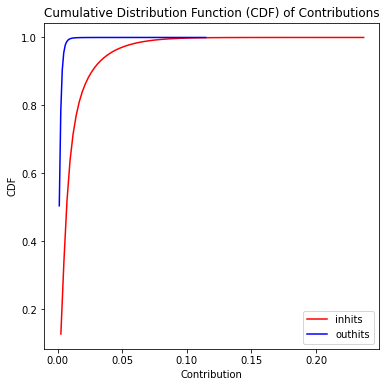

In [18]:
plt.figure(figsize=(10, 6))

# Compute the CDF for inhits_contribs
inhits_values = np.abs(inhits_contribs)
inhits_counts, inhits_bin_edges = np.histogram(inhits_values, bins=100, density=True)
inhits_cdf = np.cumsum(inhits_counts * np.diff(inhits_bin_edges))

# Compute the CDF for outhits_contribs
outhits_values = np.abs(outhits_contribs)
outhits_counts, outhits_bin_edges = np.histogram(outhits_values, bins=100, density=True)
outhits_cdf = np.cumsum(outhits_counts * np.diff(outhits_bin_edges))

# Set the figure size
plt.figure(figsize=(6, 6))

# Plot the CDFs
plt.plot(inhits_bin_edges[1:], inhits_cdf, color='red', label='inhits')
plt.plot(outhits_bin_edges[1:], outhits_cdf, color='blue', label='outhits')

# Add labels and legend
plt.xlabel('Contribution')
plt.ylabel('CDF')
plt.title('Cumulative Distribution Function (CDF) of Contributions')
plt.legend()

# Display the plot
plt.show()

In [24]:
np.abs(inhits_contribs).max()

0.23689976831277212

In [25]:
np.abs(inhits_contribs).min()

1.4163864155610402e-09

In [ ]:
# 1.4e-09 - 0.24 (0.012)
# 0 - 0.11  (0.0016)


In [20]:
np.abs(inhits_contribs).mean()

0.011451208839668997

In [26]:
np.abs(outhits_values).max()

0.11454703162113826

In [27]:
np.abs(outhits_values).min()

0.0

In [23]:
np.abs(outhits_values).mean()

0.0015614151205226457

In [18]:
np.abs(inhits_contribs).max()

0.23689976831277212

In [19]:
inhits_values.shape

(1316366,)

In [43]:
outhits_values.shape

(5462204,)

In [44]:
def plot_cdf(inhits_contribs, outhits_contribs, ax):
    # Compute the CDF for inhits_contribs
    inhits_values = np.abs(inhits_contribs)
    inhits_counts, inhits_bin_edges = np.histogram(inhits_values, bins=100, density=True)
    inhits_cdf = np.cumsum(inhits_counts * np.diff(inhits_bin_edges))

    # Compute the CDF for outhits_contribs
    outhits_values = np.abs(outhits_contribs)
    outhits_counts, outhits_bin_edges = np.histogram(outhits_values, bins=100, density=True)
    outhits_cdf = np.cumsum(outhits_counts * np.diff(outhits_bin_edges))

    # Plot the CDFs
    ax.plot(inhits_bin_edges[1:], inhits_cdf, color='red', label='inhits')
    ax.plot(outhits_bin_edges[1:], outhits_cdf, color='blue', label='outhits')

    # Add labels and legend
    ax.set_xlabel('Contribution')
    ax.set_ylabel('CDF')
    ax.set_title('Cumulative Distribution Function (CDF) of Contributions')
    ax.legend()

In [72]:
def abbreviate_motif_name(name):
    try:
        group, motif = name.split(".")

        if group == "pos_patterns":
            group_short = "+"
        elif group == "neg_patterns":
            group_short = "-"
        else:
            raise Exception

        motif_num = motif.split("_")[1]

        return f"{group_short}/{motif_num}"
    
    except:
        return name

    
def plot_hit_vs_seqlet_counts(recall_data, ax):
    x = []
    y = []
    m = []
    for k, v in recall_data.iterrows():
        #print(v)
#         x.append(v["num_hits_total"])
#         y.append(v["num_seqlets"])
        y.append(v["num_hits_total"])
        x.append(v["num_seqlets"])
        m.append(v['motif_name'])
    
    print(y,x)

    lim = max(np.amax(x), np.amax(y))

    #fig, ax = plt.subplots(figsize=(8,8))
    ax.axline((0, 0), (lim, lim), color="0.3", linewidth=0.7, linestyle=(0, (5, 5)))
    ax.scatter(x, y, s=5)
    for i, txt in enumerate(m):
        short = abbreviate_motif_name(txt)
        ax.annotate(short, (x[i], y[i]), fontsize=8)
        
    # Fit regression line in log-log scale with base 10
    log_x = np.log10(x)
    log_y = np.log10(y)
    slope, intercept = np.polyfit(log_x, log_y, 1)
    regression_line_x = np.linspace(min(x), max(x), 100)
    regression_line_y = 10**(intercept) * regression_line_x ** slope

    # Plot regression line
    ax.plot(regression_line_x, regression_line_y, color='red')
    
    print(f"Slope: {slope}")
    print(f"Intercept: {intercept}")

    ax.set_yscale('log')
    ax.set_xscale('log')

    ax.set_xlabel("Seqlets per motif")
    ax.set_ylabel("Hits per motif")

    #plt.savefig(output_path, dpi=300)
    #plt.close()

In [73]:
report_data = pd.read_csv("/mnt/lab_data2/anusri/finemo_gpu/output/572M/motif_report.tsv", sep="\t", header=0)
#plot_hit_vs_seqlet_counts(report_data, "")

[153836, 39254, 101893, 299944, 82445, 52280, 33404, 116527, 127870, 12053, 49524, 19076, 37218, 20906, 102158, 18980, 6015, 2080, 31767, 5202, 4971, 8948, 9896, 24739, 14433, 4238, 4534, 11917, 15509, 60623, 2601, 2632, 7386, 4365, 909, 11533, 2059, 1434, 1382, 4343, 185, 7617, 65, 21926, 1346, 412, 424, 93, 223, 369, 68, 546, 2043, 76, 1160, 149, 1565333, 32108] [33639, 30667, 20052, 16999, 16008, 12399, 9961, 6812, 6757, 3616, 3336, 2474, 2273, 2199, 2178, 2011, 1841, 1709, 1558, 1559, 1550, 1311, 1299, 1165, 1026, 965, 977, 947, 486, 448, 274, 248, 233, 196, 185, 173, 167, 143, 142, 126, 102, 86, 70, 66, 60, 55, 53, 47, 39, 39, 36, 35, 31, 29, 26, 24, 258, 37]
Slope: 0.822019511687658
Intercept: 1.558020254272548


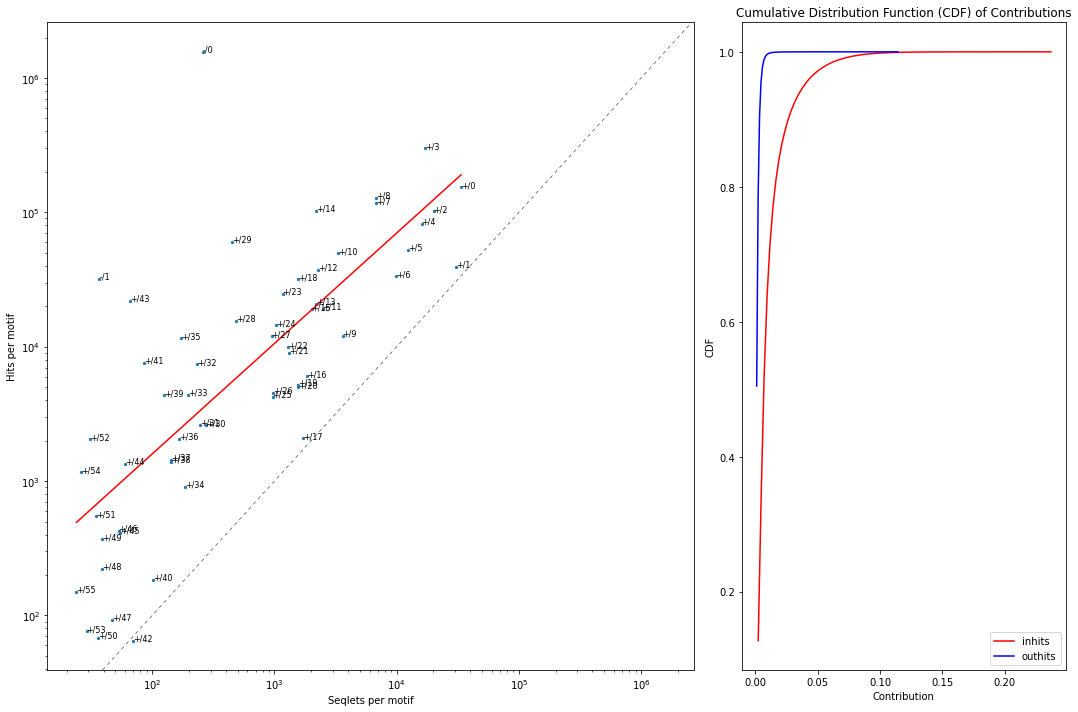

In [74]:
# Create figure with two columns
import matplotlib

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42 

fig, ax = plt.subplots(1, 2, figsize=(15, 10), gridspec_kw={'width_ratios': [2, 1]})

# Plot hit vs seqlet counts
plot_hit_vs_seqlet_counts(report_data, ax[0])

# Plot CDFs
plot_cdf(inhits_contribs, outhits_contribs, ax[1])

# Display the plot
plt.tight_layout()
plt.savefig("figures/finemo-vs-modisco.pdf", transparent=True, dpi=300)
plt.show()

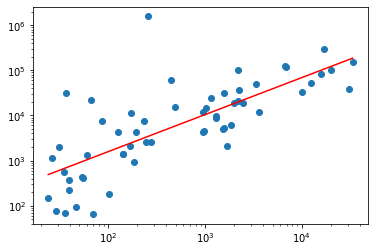

In [79]:
# y = [153836, 39254, 101893, 299944, 82445, 52280, 33404, 116527, 127870, 12053, 49524, 19076, 37218, 20906, 102158, 18980, 6015, 2080, 31767, 5202, 4971, 8948, 9896, 24739, 14433, 4238, 4534, 11917, 15509, 60623, 2601, 2632, 7386, 4365, 909, 11533, 2059, 1434, 1382, 4343, 185, 7617, 65, 21926, 1346, 412, 424, 93, 223, 369, 68, 546, 2043, 76, 1160, 149, 1565333, 32108] 
# x = [33639, 30667, 20052, 16999, 16008, 12399, 9961, 6812, 6757, 3616, 3336, 2474, 2273, 2199, 2178, 2011, 1841, 1709, 1558, 1559, 1550, 1311, 1299, 1165, 1026, 965, 977, 947, 486, 448, 274, 248, 233, 196, 185, 173, 167, 143, 142, 126, 102, 86, 70, 66, 60, 55, 53, 47, 39, 39, 36, 35, 31, 29, 26, 24, 258, 37]

# intercept=1.558
# slope=0.82
# plt.scatter(x, y)
# plt.xscale("log")
# plt.yscale("log")

# # Add regression line
# xx = np.logspace(np.log10(min(x)), np.log10(max(x)), 100)
# yy = 10**(intercept) * xx**slope
# plt.plot(xx, yy, 'r-')